Sales Data:


,Date,Region,Category,Product,Quantity,UnitPrice,TotalSales,YearMonth
0,2025-01-01,North,Clothing,Pen,4,1070,4280,2025-01
1,2025-01-02,South,Stationery,Table,3,1135,3405,2025-01
2,2025-01-03,East,Clothing,Chair,7,1453,10171,2025-01
3,2025-01-04,North,Electronics,Laptop,8,835,6680,2025-01
4,2025-01-05,North,Stationery,Pen,4,883,3532,2025-01



Target Data:


,YearMonth,TargetSales
0,2025-01,57842
1,2025-02,48271
2,2025-03,33266
3,2025-04,30666
4,2025-05,34188



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        200 non-null    datetime64[ns]
 1   Region      200 non-null    object        
 2   Category    200 non-null    object        
 3   Product     200 non-null    object        
 4   Quantity    200 non-null    int64         
 5   UnitPrice   200 non-null    int64         
 6   TotalSales  200 non-null    int64         
 7   YearMonth   200 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 12.6+ KB

Missing Values:
Date          0
Region        0
Category      0
Product       0
Quantity      0
UnitPrice     0
TotalSales    0
YearMonth     0
dtype: int64

========== KPI VALUES ==========
Total Sales: 962716
Total Quantity: 966
Average Order Value: 4813.58
Total Orders: 200


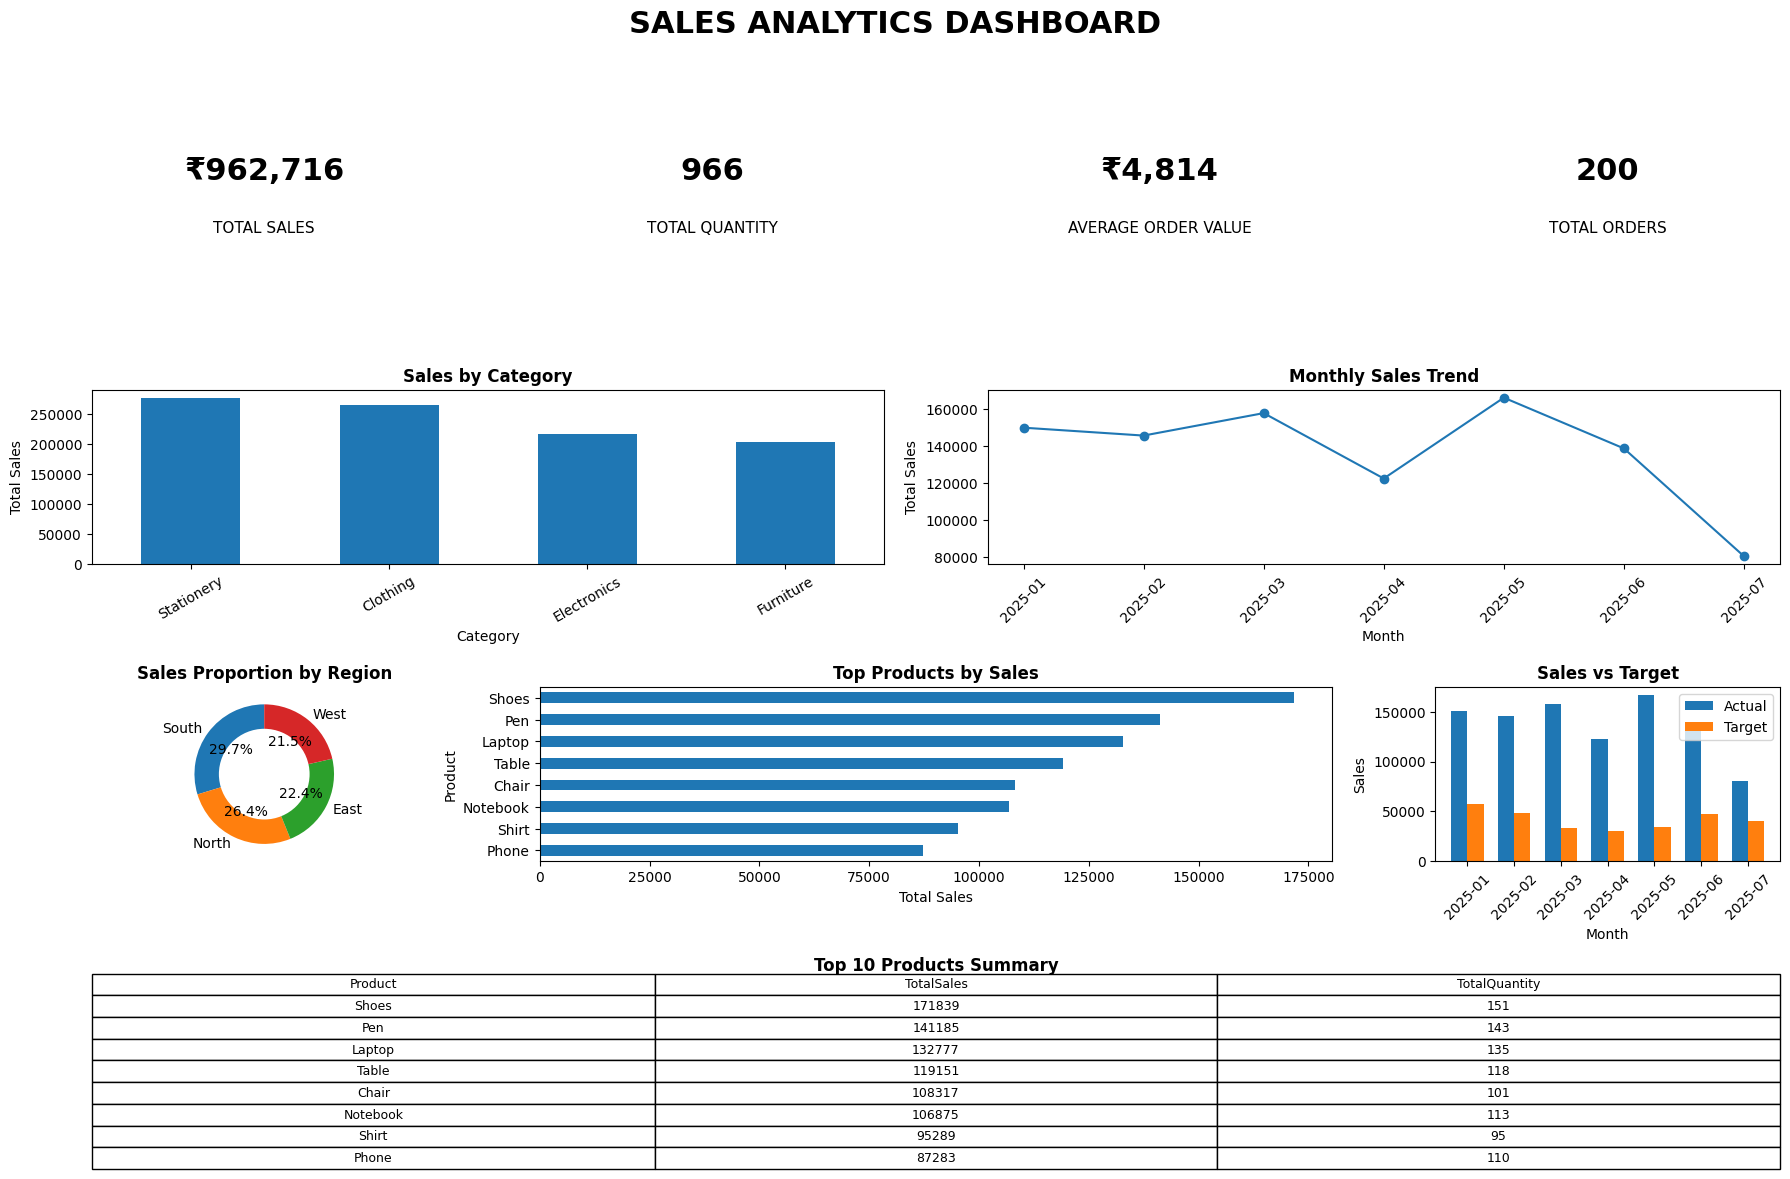

In [1]:
# ============================================================
# SALES DASHBOARD - PYTHON VERSION OF POWER BI TASK
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For reproducible data
np.random.seed(42)


# ============================================================
# 1. CREATE SAMPLE SALES DATA
# ============================================================

n = 200

sales_data = {
    'Date': pd.date_range(
        start='2025-01-01',
        periods=n,
        freq='D'
    ),

    'Region': np.random.choice(
        ['East', 'West', 'North', 'South'],
        n
    ),

    'Category': np.random.choice(
        ['Electronics', 'Furniture', 'Clothing', 'Stationery'],
        n
    ),

    'Product': np.random.choice(
        ['Laptop', 'Phone', 'Chair', 'Table',
         'Shirt', 'Shoes', 'Notebook', 'Pen'],
        n
    ),

    'Quantity': np.random.randint(1, 10, n),

    'UnitPrice': np.random.randint(100, 2000, n)
}

df = pd.DataFrame(sales_data)


# ============================================================
# 2. CLEAN & TRANSFORM DATA
# ============================================================

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create TotalSales column
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove unnecessary whitespace from text columns
text_columns = [
    'Region',
    'Category',
    'Product'
]

for col in text_columns:
    df[col] = df[col].str.strip()

# Create YearMonth column
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)


# ============================================================
# 3. CREATE TARGET DATA
# ============================================================

targets = pd.DataFrame({
    'YearMonth': sorted(df['YearMonth'].unique())
})

# Example monthly targets
targets['TargetSales'] = np.random.randint(
    30000,
    60000,
    len(targets)
)

print("Sales Data:")
display(df.head())

print("\nTarget Data:")
display(targets.head())


# ============================================================
# 4. BASIC INFORMATION
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 5. KPI CALCULATIONS
# ============================================================

total_sales = df['TotalSales'].sum()

total_quantity = df['Quantity'].sum()

avg_order_value = df['TotalSales'].mean()

total_orders = len(df)

print("\n========== KPI VALUES ==========")
print("Total Sales:", total_sales)
print("Total Quantity:", total_quantity)
print("Average Order Value:", round(avg_order_value, 2))
print("Total Orders:", total_orders)


# ============================================================
# 6. SALES BY CATEGORY
# ============================================================

category_sales = (
    df.groupby('Category')['TotalSales']
    .sum()
    .sort_values(ascending=False)
)


# ============================================================
# 7. MONTHLY SALES TREND
# ============================================================

monthly_sales = (
    df.groupby('YearMonth')['TotalSales']
    .sum()
    .reset_index()
)


# ============================================================
# 8. SALES BY REGION
# ============================================================

region_sales = (
    df.groupby('Region')['TotalSales']
    .sum()
    .sort_values(ascending=False)
)


# ============================================================
# 9. TOP 10 PRODUCTS
# ============================================================

top_products = (
    df.groupby('Product')
    .agg(
        TotalSales=('TotalSales', 'sum'),
        TotalQuantity=('Quantity', 'sum')
    )
    .sort_values(
        'TotalSales',
        ascending=False
    )
    .head(10)
)


# ============================================================
# 10. SALES VS TARGET
# ============================================================

target_comparison = monthly_sales.merge(
    targets,
    on='YearMonth',
    how='left'
)

target_comparison['Variance'] = (
    target_comparison['TotalSales']
    - target_comparison['TargetSales']
)


# ============================================================
# 11. CREATE DASHBOARD
# ============================================================

fig = plt.figure(figsize=(18, 12))

fig.suptitle(
    'SALES ANALYTICS DASHBOARD',
    fontsize=22,
    fontweight='bold'
)


# ------------------------------------------------------------
# KPI 1 - TOTAL SALES
# ------------------------------------------------------------

ax1 = plt.subplot2grid(
    (4, 4),
    (0, 0)
)

ax1.text(
    0.5,
    0.55,
    f'₹{total_sales:,.0f}',
    ha='center',
    va='center',
    fontsize=22,
    fontweight='bold'
)

ax1.text(
    0.5,
    0.20,
    'TOTAL SALES',
    ha='center',
    fontsize=11
)

ax1.axis('off')


# ------------------------------------------------------------
# KPI 2 - TOTAL QUANTITY
# ------------------------------------------------------------

ax2 = plt.subplot2grid(
    (4, 4),
    (0, 1)
)

ax2.text(
    0.5,
    0.55,
    f'{total_quantity:,}',
    ha='center',
    va='center',
    fontsize=22,
    fontweight='bold'
)

ax2.text(
    0.5,
    0.20,
    'TOTAL QUANTITY',
    ha='center',
    fontsize=11
)

ax2.axis('off')


# ------------------------------------------------------------
# KPI 3 - AVERAGE ORDER VALUE
# ------------------------------------------------------------

ax3 = plt.subplot2grid(
    (4, 4),
    (0, 2)
)

ax3.text(
    0.5,
    0.55,
    f'₹{avg_order_value:,.0f}',
    ha='center',
    va='center',
    fontsize=22,
    fontweight='bold'
)

ax3.text(
    0.5,
    0.20,
    'AVERAGE ORDER VALUE',
    ha='center',
    fontsize=11
)

ax3.axis('off')


# ------------------------------------------------------------
# KPI 4 - TOTAL ORDERS
# ------------------------------------------------------------

ax4 = plt.subplot2grid(
    (4, 4),
    (0, 3)
)

ax4.text(
    0.5,
    0.55,
    f'{total_orders:,}',
    ha='center',
    va='center',
    fontsize=22,
    fontweight='bold'
)

ax4.text(
    0.5,
    0.20,
    'TOTAL ORDERS',
    ha='center',
    fontsize=11
)

ax4.axis('off')


# ============================================================
# BAR CHART - SALES BY CATEGORY
# ============================================================

ax5 = plt.subplot2grid(
    (4, 4),
    (1, 0),
    colspan=2
)

category_sales.plot(
    kind='bar',
    ax=ax5
)

ax5.set_title(
    'Sales by Category',
    fontweight='bold'
)

ax5.set_xlabel('Category')
ax5.set_ylabel('Total Sales')

ax5.tick_params(axis='x', rotation=30)


# ============================================================
# LINE CHART - MONTHLY SALES TREND
# ============================================================

ax6 = plt.subplot2grid(
    (4, 4),
    (1, 2),
    colspan=2
)

ax6.plot(
    monthly_sales['YearMonth'],
    monthly_sales['TotalSales'],
    marker='o'
)

ax6.set_title(
    'Monthly Sales Trend',
    fontweight='bold'
)

ax6.set_xlabel('Month')
ax6.set_ylabel('Total Sales')

ax6.tick_params(
    axis='x',
    rotation=45
)


# ============================================================
# DONUT CHART - SALES BY REGION
# ============================================================

ax7 = plt.subplot2grid(
    (4, 4),
    (2, 0)
)

ax7.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

# Create donut hole
centre_circle = plt.Circle(
    (0, 0),
    0.65,
    fc='white'
)

ax7.add_artist(centre_circle)

ax7.set_title(
    'Sales Proportion by Region',
    fontweight='bold'
)


# ============================================================
# TOP 10 PRODUCTS
# ============================================================

ax8 = plt.subplot2grid(
    (4, 4),
    (2, 1),
    colspan=2
)

top_products['TotalSales'].sort_values().plot(
    kind='barh',
    ax=ax8
)

ax8.set_title(
    'Top Products by Sales',
    fontweight='bold'
)

ax8.set_xlabel('Total Sales')
ax8.set_ylabel('Product')


# ============================================================
# SALES VS TARGET
# ============================================================

ax9 = plt.subplot2grid(
    (4, 4),
    (2, 3)
)

x = np.arange(
    len(target_comparison)
)

width = 0.35

ax9.bar(
    x - width/2,
    target_comparison['TotalSales'],
    width,
    label='Actual'
)

ax9.bar(
    x + width/2,
    target_comparison['TargetSales'],
    width,
    label='Target'
)

ax9.set_title(
    'Sales vs Target',
    fontweight='bold'
)

ax9.set_xlabel('Month')
ax9.set_ylabel('Sales')

ax9.set_xticks(x)

ax9.set_xticklabels(
    target_comparison['YearMonth'],
    rotation=45
)

ax9.legend()


# ============================================================
# TOP 10 PRODUCT TABLE
# ============================================================

ax10 = plt.subplot2grid(
    (4, 4),
    (3, 0),
    colspan=4
)

ax10.axis('off')

table_data = top_products.reset_index()

table = ax10.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)

table.set_fontsize(9)

table.scale(
    1,
    1.5
)

ax10.set_title(
    'Top 10 Products Summary',
    fontweight='bold',
    pad=10
)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()